# Análisis Exploratorio de Datos (EDA)

## Introducción

El análisis de sentimientos y la clasificación automática de opiniones constituyen una de las aplicaciones más relevantes del Procesamiento del Lenguaje Natural (Natural Language Processing, NLP). En este proyecto se trabajará con un conjunto de reseñas reales de productos de comercio electrónico con el objetivo de desarrollar un modelo capaz de predecir la valoración otorgada por los usuarios a partir del contenido textual de sus comentarios.

El dataset seleccionado corresponde a **Women's E-Commerce Clothing Reviews**, e incluye reseñas realizadas por clientes sobre diferentes prendas de vestir. Además del texto de cada opinión, contiene información complementaria como la puntuación asignada (Rating), la recomendación del producto, la categoría del artículo y otras variables descriptivas.

Durante este notebook se realizará un Análisis Exploratorio de Datos (EDA) con el propósito de comprender la estructura del conjunto de datos, evaluar su calidad, identificar posibles problemas (valores faltantes, duplicados o desbalance de clases) y explorar las principales características de las reseñas. Los resultados obtenidos servirán como base para las etapas posteriores de preprocesamiento, representación numérica del texto mediante TF-IDF y entrenamiento de modelos de clasificación utilizando técnicas de Machine Learning y Deep Learning.


## Contenido

1. Introducción
2. Importación de librerías
3. Carga del dataset
4. Información general del conjunto de datos
5. Calidad de los datos
6. Análisis de la variable objetivo
7. Exploración del texto de las reseñas
8. Análisis de variables adicionales
9. Conclusiones del EDA

## Importación de librerías

Se importan las bibliotecas que serán utilizadas durante el análisis exploratorio. Estas herramientas permiten realizar la manipulación del conjunto de datos, generar visualizaciones estadísticas y construir representaciones gráficas que facilitan la comprensión de las características del dataset.

Además, se establecen algunas configuraciones generales de visualización y una semilla aleatoria (`RANDOM_STATE`) para garantizar la reproducibilidad de los resultados obtenidos a lo largo del proyecto.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
# ==============================
# Manipulación de datos
# ==============================

import pandas as pd
import numpy as np

# ==============================
# Visualización
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

# ==============================
# Configuración
# ==============================

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Configuración de visualización
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 120)

# Semilla para reproducibilidad
RANDOM_STATE = 42

## Carga del dataset

En esta sección se carga el conjunto de datos que será utilizado durante el desarrollo del proyecto. Para favorecer la reutilización del código y mantener una estructura modular, la lectura del archivo CSV se realiza mediante la función `load_data()` implementada en el módulo `src.data.load_data`.

Una vez cargado el dataset, se verifica correctamente su estructura mostrando sus dimensiones y las primeras observaciones. Esta primera inspección permite confirmar que la información fue importada de manera adecuada antes de comenzar el análisis exploratorio.

In [5]:
from pathlib import Path
import sys

# Agregar la raíz del proyecto al PATH
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data.load_data import load_data

# Cargar dataset
df = load_data()

print(f"Dimensiones del dataset: {df.shape}")

df.head()

Dimensiones del dataset: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i n...",5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered th...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get no...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length t...,5,1,6,General,Tops,Blouses


## Información general del conjunto de datos

Antes de comenzar el análisis exploratorio detallado, resulta conveniente realizar una inspección general del dataset. En esta etapa se examinan sus dimensiones, las primeras observaciones, la estructura de las variables y algunas estadísticas descriptivas.

Este análisis inicial permite comprender la naturaleza de la información disponible, identificar el tipo de datos presente en cada columna y detectar posibles particularidades que deberán abordarse durante el proceso de limpieza y preprocesamiento.

In [3]:
# Dimensiones del dataset
rows, cols = df.shape

print(f"Número de observaciones: {rows:,}")
print(f"Número de variables: {cols}")

Número de observaciones: 23,486
Número de variables: 11


In [4]:
# Primeras observaciones
display(df.head())

# Últimas observaciones
display(df.tail())

# Muestra aleatoria
display(df.sample(5, random_state=RANDOM_STATE))

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i n...",5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered th...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get no...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length t...,5,1,6,General,Tops,Blouses


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a great price! it's very easy to slip on and has a v...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stretchy, shiny material. cut is flattering and drapes...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see through. this never would have worked for me. i'm glad i...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties and we","I bought this dress for a wedding i have this summer, and it's so cute. unfortunately the fit is...",3,1,2,General,Dresses,Dresses
23485,23485,1104,52,Please make more like this one!,"This dress in a lovely platinum is feminine and fits perfectly, easy to wear and comfy, too! hig...",5,1,22,General Petite,Dresses,Dresses


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
1297,1297,1095,34,Size up if busty,I agree with the other reviewer that the color isn't as pink in person and more subtle. my thoug...,4,1,19,General,Dresses,Dresses
7228,7228,903,57,Snap front hoodie,I have many sweaters but i bought this during the sale and it is very soft and comfortable.,4,1,0,General Petite,Tops,Fine gauge
21410,21410,830,56,Adorable,Beautiful top but runs a whole size small. gave to my daughter who loved!,4,1,3,General,Tops,Blouses
8358,8358,1047,36,Fraying after 2 wears!,"I loved these pants.they are so comfortable. however, after just wearing them twice, the threads...",3,0,3,General Petite,Bottoms,Pants
20840,20840,1110,30,Fabulous material....,"I ordered this dress in a petite but it arrived in a regular, the rest fit and in the meantime t...",5,1,0,General,Dresses,Dresses


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [7]:
# Variables numéricas
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,23486.0,11742.500000,6779.968547,0.0,5871.25,11742.5,17613.75,23485.0
Clothing ID,23486.0,918.118709,203.298980,0.0,861.00,936.0,1078.00,1205.0
Age,23486.0,43.198544,12.279544,18.0,34.00,41.0,52.00,99.0
Rating,23486.0,4.196032,1.110031,1.0,4.00,5.0,5.00,5.0
Recommended IND,23486.0,0.822362,0.382216,0.0,1.00,1.0,1.00,1.0
Positive Feedback Count,23486.0,2.535936,5.702202,0.0,0.00,1.0,3.00,122.0


In [8]:
# Variables categóricas
display(df.describe(include="object").T)

,count,unique,top,freq
Title,19676,13993,Love it!,136
Review Text,22641,22634,Perfect fit and i've gotten so many compliments. i buy all my suits from here now!,3
Division Name,23472,3,General,13850
Department Name,23472,6,Tops,10468
Class Name,23472,20,Dresses,6319


### Conclusiones

La inspección inicial muestra que el conjunto de datos está compuesto por **23.486 observaciones** y **11 variables**, que incluyen información numérica, categórica y textual. La variable de mayor interés para este proyecto corresponde al contenido de las reseñas (`Review Text`), mientras que la variable objetivo será la valoración otorgada por los usuarios (`Rating`).

A partir de `df.info()` se observa que el dataset combina **6 variables numéricas** y **5 variables categóricas**, presentando un tamaño reducido (aproximadamente **2 MB**), lo que permitirá realizar el procesamiento y entrenamiento de modelos de manera eficiente.

Asimismo, la inspección descriptiva muestra que la mayoría de las valoraciones se concentran en puntuaciones altas (mediana igual a **5**), lo que sugiere un posible desbalance de clases que será analizado con mayor profundidad en las siguientes secciones. También se identifican algunas columnas con valores faltantes, aspecto que será abordado durante la etapa de limpieza y preprocesamiento.

## Calidad de los datos

Antes de comenzar el preprocesamiento del texto resulta necesario evaluar la calidad del conjunto de datos. En esta sección se analizará la presencia de valores faltantes, registros duplicados, posibles columnas irrelevantes y la consistencia de los tipos de datos.

El objetivo es identificar aquellos aspectos que puedan afectar el entrenamiento del modelo y definir las transformaciones que deberán aplicarse durante la etapa de limpieza de datos.

In [ ]:
missing_summary = pd.DataFrame({
    "Valores faltantes": df.isnull().sum(),
    "Porcentaje (%)": (df.isnull().mean()*100).round(2)
})

display(
    missing_summary.sort_values(
        "Porcentaje (%)",
        ascending=False
    )
)

,Valores faltantes,Porcentaje (%)
Title,3810,16.22
Review Text,845,3.60
Department Name,14,0.06
Class Name,14,0.06
Division Name,14,0.06
Unnamed: 0,0,0.00
Clothing ID,0,0.00
Age,0,0.00
Rating,0,0.00
Recommended IND,0,0.00


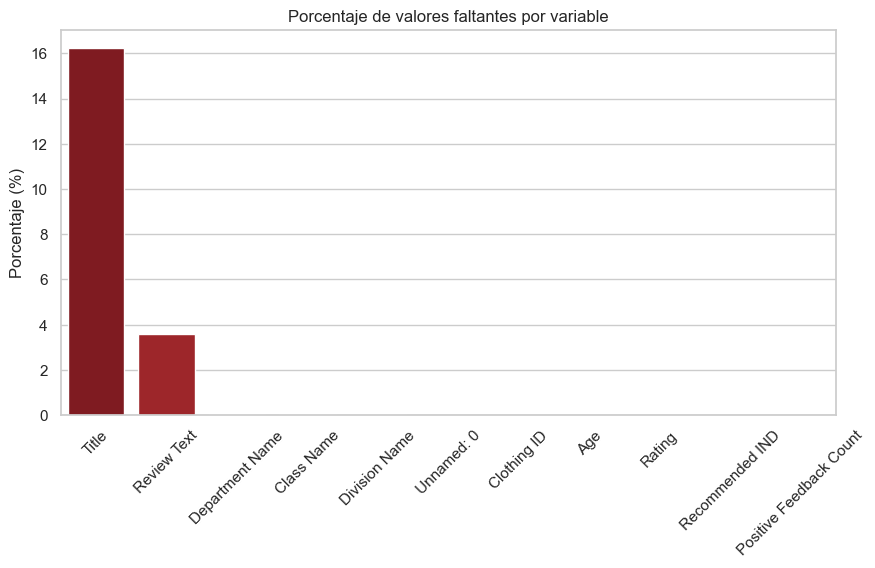

In [25]:
# Porcentaje de valores faltantes
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)
plt.figure(figsize=(10,5))

sns.barplot(
    x=missing_percentage.index,
    y=missing_percentage.values,
    palette="Reds_r"
)

plt.xticks(rotation=45)
plt.ylabel("Porcentaje (%)")
plt.xlabel("")
plt.title("Porcentaje de valores faltantes por variable")

plt.show()

In [14]:
duplicates = df.duplicated().sum()

print(f"Registros duplicados: {duplicates}")

Registros duplicados: 0


In [20]:
for column in df.columns:
    print(column)

Unnamed: 0
Clothing ID
Age
Title
Review Text
Rating
Recommended IND
Positive Feedback Count
Division Name
Department Name
Class Name


In [21]:
display(df.head())

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i n...",5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered th...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get no...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length t...,5,1,6,General,Tops,Blouses


In [22]:
display(df.dtypes.to_frame(name="Tipo de dato"))

,Tipo de dato
Unnamed: 0,int64
Clothing ID,int64
Age,int64
Title,object
Review Text,object
Rating,int64
Recommended IND,int64
Positive Feedback Count,int64
Division Name,object
Department Name,object


In [23]:
df.select_dtypes(include="object").columns

Index(['Title', 'Review Text', 'Division Name', 'Department Name', 'Class Name'], dtype='object')

### Conclusiones

El análisis de calidad de los datos muestra que el conjunto presenta una estructura consistente y adecuada para el desarrollo del proyecto. No se identificaron registros duplicados y la mayoría de las variables se encuentran completas, lo que reduce la necesidad de aplicar procesos de limpieza estructural.

Los valores faltantes se concentran principalmente en las variables **Title** (16,22 %) y, en menor medida, **Review Text** (3,60 %). Además, las variables categóricas **Division Name**, **Department Name** y **Class Name** presentan un porcentaje de valores ausentes inferior al 0,1 %, por lo que su impacto sobre el análisis resulta prácticamente despreciable.

Se observa también que la columna **Unnamed: 0** corresponde únicamente al índice original del archivo y no aporta información útil para el problema de clasificación, por lo que será eliminada durante el preprocesamiento.

En la siguiente etapa se abordará la limpieza y transformación del texto, definiendo el tratamiento de los valores faltantes y preparando las reseñas para su representación numérica y posterior entrenamiento del modelo de clasificación.

## Distribución de la variable objetivo

Antes de construir el modelo resulta fundamental analizar la distribución de la variable objetivo (`Rating`). Este análisis permite evaluar si el problema presenta un balance adecuado entre clases o si existe un desbalance que pueda afectar el entrenamiento del clasificador.

Además de estudiar la frecuencia absoluta y relativa de las calificaciones, se explorará la distribución mediante diferentes visualizaciones para comprender mejor el comportamiento general del conjunto de datos.

In [6]:
rating_summary = pd.DataFrame({
    "Cantidad de reseñas": df["Rating"]
    .value_counts()
    .sort_index(),
    "Porcentaje (%)": df["Rating"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
})

display(
    rating_summary.sort_values(
        "Porcentaje (%)",
        ascending=False
    )
)

,Cantidad de reseñas,Porcentaje (%)
Rating,,
5,13131,55.909904
4,5077,21.617134
3,2871,12.224304
2,1565,6.663544
1,842,3.585115


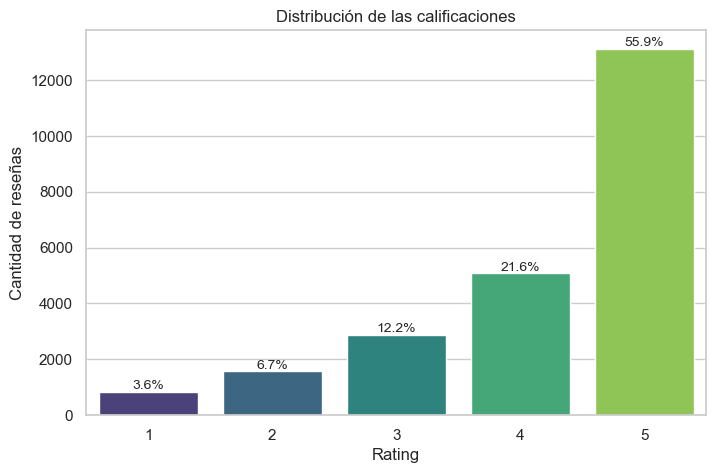

In [32]:
counts = (
    df["Rating"]
    .value_counts()
    .sort_index()
)

percentages = counts / counts.sum() * 100

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    palette="viridis"
)

for i, (count, pct) in enumerate(zip(counts.values, percentages)):
    ax.text(
        i,
        count,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Distribución de las calificaciones")
plt.xlabel("Rating")
plt.ylabel("Cantidad de reseñas")

plt.show()

In [30]:
print(f"Cantidad de clases: {df['Rating'].nunique()}")

print(f"Rating mínimo: {df['Rating'].min()}")

print(f"Rating máximo: {df['Rating'].max()}")

print(f"Rating promedio: {df['Rating'].mean():.2f}")

Cantidad de clases: 5
Rating mínimo: 1
Rating máximo: 5
Rating promedio: 4.20


### Conclusiones

La variable objetivo (`Rating`) presenta una distribución claramente desbalanceada hacia las calificaciones positivas. Más de la mitad de las reseñas (**55,9 %**) corresponden a **5 estrellas**, mientras que las valoraciones de **4 estrellas** representan otro **21,6 %** del conjunto de datos. En conjunto, aproximadamente el **77,5 %** de las observaciones corresponden a calificaciones de 4 o 5 estrellas.

Por el contrario, las reseñas negativas (1 y 2 estrellas) constituyen únicamente alrededor del **10,3 %** del total, evidenciando un desbalance moderado entre las clases. Este comportamiento es consistente con lo observado en plataformas de comercio electrónico, donde los usuarios tienden a compartir con mayor frecuencia experiencias de compra satisfactorias.

Aunque el conjunto de datos no presenta una distribución uniforme entre las categorías, todas las clases cuentan con una cantidad suficiente de observaciones para abordar el problema como una tarea de clasificación multiclase. No obstante, durante la etapa de evaluación será importante complementar la métrica de precisión (accuracy) con indicadores como **Precision**, **Recall** y **F1-score**, a fin de medir adecuadamente el desempeño del modelo sobre las clases menos representadas.

## Exploración de variables predictoras

Además del texto de las reseñas, el conjunto de datos contiene variables demográficas y categóricas que aportan contexto sobre el producto evaluado y el perfil del consumidor.

Si bien estas variables no serán utilizadas como entrada del modelo de clasificación desarrollado en este proyecto, su análisis permite comprender mejor la composición del dataset e identificar posibles patrones descriptivos.

In [7]:
display(df["Age"].describe().to_frame().T)

,count,mean,std,min,25%,50%,75%,max
Age,23486.0,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0


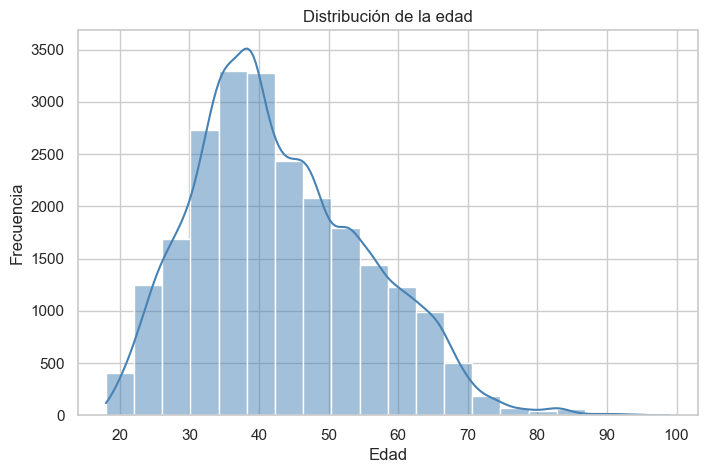

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Distribución de la edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

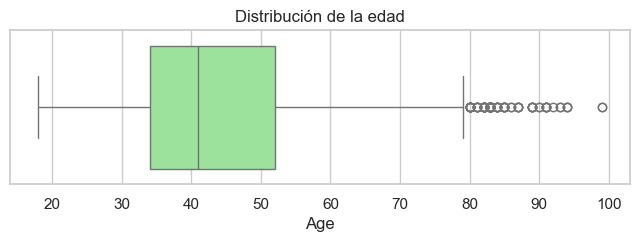

In [9]:
plt.figure(figsize=(8,2))

sns.boxplot(
    data=df,
    x="Age",
    color="lightgreen"
)

plt.title("Distribución de la edad")

plt.show()

In [10]:
department_counts = (
    df["Department Name"]
      .value_counts()
)

display(department_counts)

Department Name
Tops        10468
Dresses      6319
Bottoms      3799
Intimate     1735
Jackets      1032
Trend         119
Name: count, dtype: int64

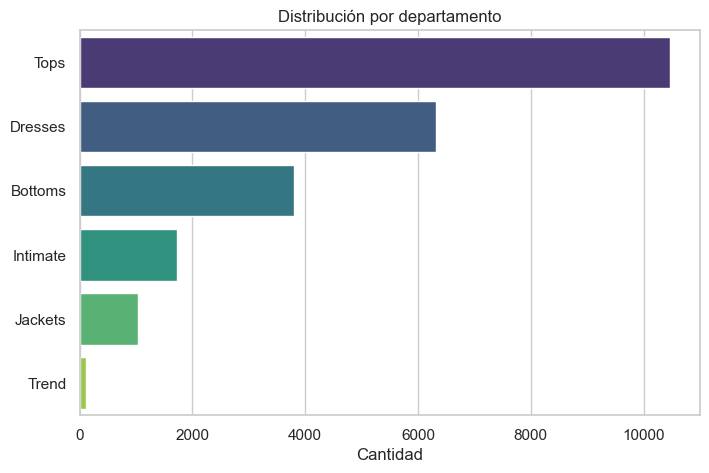

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="Department Name",
    order=department_counts.index,
    palette="viridis"
)

plt.title("Distribución por departamento")

plt.xlabel("Cantidad")

plt.ylabel("")

plt.show()

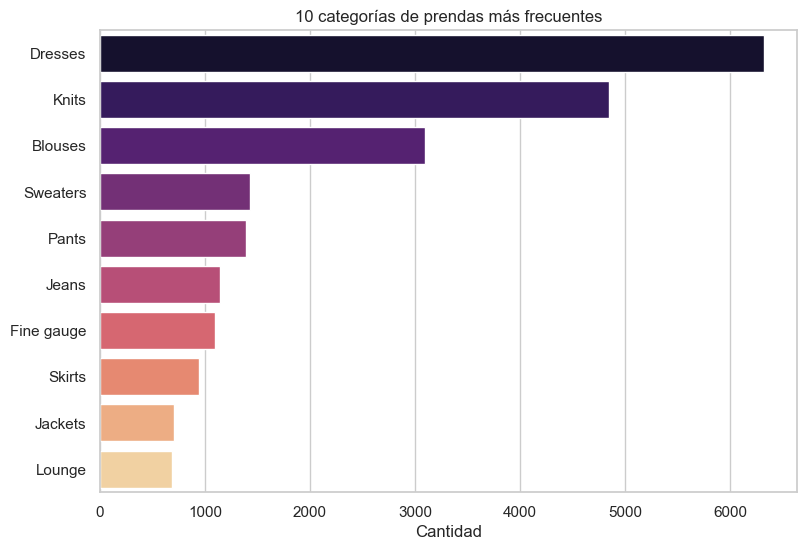

In [12]:
top_classes = (
    df["Class Name"]
      .value_counts()
      .head(10)
)

plt.figure(figsize=(9,6))

sns.barplot(
    x=top_classes.values,
    y=top_classes.index,
    palette="magma"
)

plt.title("10 categorías de prendas más frecuentes")

plt.xlabel("Cantidad")

plt.ylabel("")

plt.show()

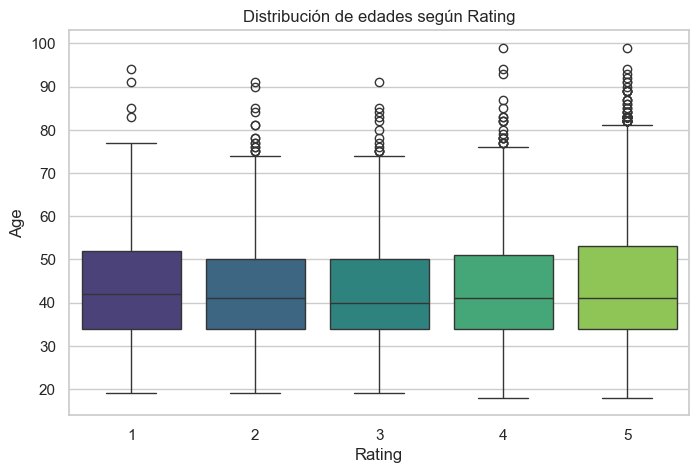

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Rating",
    y="Age",
    palette="viridis"
)

plt.title("Distribución de edades según Rating")

plt.show()

### Conclusiones

El análisis descriptivo muestra que la mayoría de las reseñas provienen de consumidores adultos, con una concentración de edades entre los **30 y 50 años**, una mediana cercana a los **41 años** y algunos valores extremos correspondientes a usuarios de mayor edad.

En cuanto a la composición del catálogo, las reseñas se concentran principalmente en los departamentos **Tops** y **Dresses**, siendo esta última también la categoría específica más frecuente. Esto evidencia que el conjunto de datos no presenta una distribución uniforme entre los distintos tipos de prendas, aunque dicha característica no afecta el objetivo del proyecto.

Por último, al comparar la distribución de edades según la calificación otorgada, no se observan diferencias relevantes entre los distintos niveles de *Rating*. Esto sugiere que la edad del consumidor no parece constituir un factor determinante en la valoración del producto, reforzando la hipótesis de que el contenido textual de las reseñas será la principal fuente de información para el modelo de clasificación.